<a href="https://colab.research.google.com/github/saladnga/CS4410-Homeworks/blob/main/CS4410_HW5_VuHoang_1677986.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. (50%) 15.18 (Project: Determine k in k-Means Clustering) on page 661.**

**Import libraries**

In [1]:
from sklearn import datasets
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
iris = datasets.load_iris()
X = iris.data
wcss = []

**Apply KMeans algorithm**

In [5]:
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42, n_init="auto")
  kmeans.fit(X)
  wcss.append(kmeans.inertia_)

**Visualize using matplotlib**

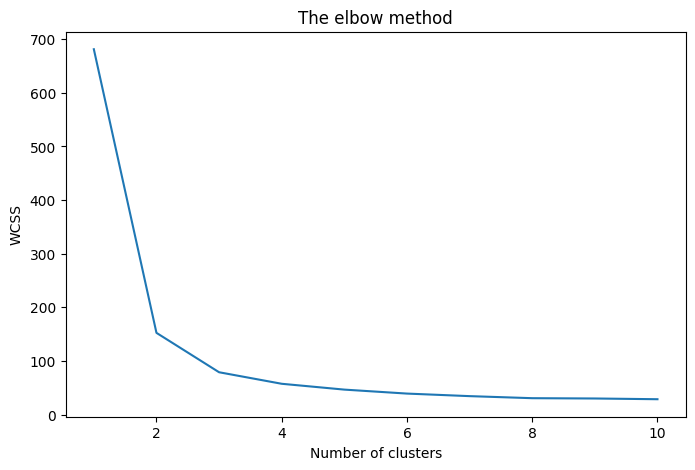

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# **2. (50%) Get MNIST dataset as the instructions in 15.21. Use PCA dimensional reduction for logistic regression on MNIST to show how much PCA can help to speed up logistic regression.**

**Import libraries**

In [8]:
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import linear_model
from sklearn.metrics import accuracy_score

**Fetch MNIST dataset**

In [26]:
mnist = fetch_openml('mnist_784')
X = mnist.data
y = mnist.target

**Split into test data and train data**

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Apply StandardScaler()**

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Use Logistic Regression without PCA**

In [29]:
logisticRegr_no_pca = linear_model.LogisticRegression(solver = 'lbfgs')

**Calculate the time and accuracy score**

In [30]:
start_time_no_pca = time.time()
logisticRegr_no_pca.fit(X_train_scaled, y_train)
end_time_no_pca = time.time()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
time_no_pca = end_time_no_pca - start_time_no_pca
y_pred_no_pca = logisticRegr_no_pca.predict(X_test_scaled)
accuracy_no_pca = accuracy_score(y_test, y_pred_no_pca)

In [32]:
print(f"Time taken (Without PCA): {time_no_pca:.2f} seconds")
print(f"Accuracy (Without PCA): {accuracy_no_pca:.4f}")

Time taken (Without PCA): 42.12 seconds
Accuracy (Without PCA): 0.9150


**Apply PCA(0.95)**

In [33]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Number of PCA components retained for 95% variance: {pca.n_components_}")

Number of PCA components retained for 95% variance: 330


**Apply Logistic Regression**

In [34]:
logisticRegr_pca = linear_model.LogisticRegression(solver = 'lbfgs')

**Calculate the time and accuracy score with PCA**

In [35]:
start_time_pca = time.time()
logisticRegr_pca.fit(X_train_pca, y_train)
end_time_pca = time.time()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
time_pca = end_time_pca - start_time_pca
y_pred_pca = logisticRegr_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)

In [37]:
print(f"Time taken (With PCA): {time_pca:.2f} seconds")
print(f"Accuracy (With PCA): {accuracy_pca:.4f}")

Time taken (With PCA): 20.61 seconds
Accuracy (With PCA): 0.9216


**Comparison Summary**

In [43]:
print("Comparison Summary:\n")
print(f"Training time without PCA: {time_no_pca:.4f} seconds")
print(f"Training time with PCA: {time_pca:.4f} seconds")
print(f"Time saved using PCA: {time_no_pca - time_pca:.4f} seconds")
print(f"PCA speed improvement: {time_no_pca/time_pca:.2f}x faster \n")
print(f"Accuracy without PCA: {accuracy_no_pca:.4f}")
print(f"Accuracy with PCA: {accuracy_pca:.4f}")
print(f"Accuracy difference: {accuracy_pca - accuracy_no_pca:.4f}")

Comparison Summary:

Training time without PCA: 42.1238 seconds
Training time with PCA: 20.6094 seconds
Time saved using PCA: 21.5144 seconds
PCA speed improvement: 2.04x faster 

Accuracy without PCA: 0.9150
Accuracy with PCA: 0.9216
Accuracy difference: 0.0066
